# The 2-D wave equation *case* — explicit vs. implicit, through the real frontend

The companion notebook, `jfnk_solver_exploration.ipynb`, builds the wave
equation's state/system by hand to explore `warpSPHIntegrators`' solver
interface in isolation. This notebook instead runs `warpSPH`'s **registered
`waveEquationCase`** — the same `Case`/`CaseSpec`/`buildContext` machinery
every `examples/*/0N-*.ipynb` notebook in this repo uses, with its normal
2-D setup (two point sources, an obstacle of reduced wave speed, an
absorbing border) — and compares an **explicit** run (`RK4`, the case's own
default) against an **implicit** one (`SDIRK2` + `JFNKSolver`) in separate
cells, at the same `dt` and then at a `dt` well past where the explicit
scheme survives.

**Why this case is actually a good implicit-solver demo, not just a
convenient one to reuse**: `cases/waveEquation.py`'s own defaults comment
says it directly — the case's absorbing border damping is *strong*
(`dampingStrength=48`) specifically so it actually absorbs outgoing waves,
and that strong linear damping term is what forces explicit `RK4` onto a
tight `cflFactor=0.1` rather than the `0.3` most fluid cases use. That is a
textbook case for an L-stable implicit scheme: the stiffness comes from a
*linear*, `warpSPHCore`-operator-free term (`-damping*v`, plain elementwise
arithmetic), so both `JFNKSolver` matvecs handle it with no new derivation
at all — the exact same `f_wave_equation` this whole case already calls.

**Requires** the same environment as the companion notebook (`warp` conda
env, CUDA GPU or CPU fallback).

In [1]:
%matplotlib widget
import math

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import torch

import warp as wp
wp.init()

plt.rcParams['figure.figsize'] = (7, 4.5)
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

Warp 1.16.0 initialized:
   CUDA Toolkit 12.9, Driver 13.3
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 6000 Blackwell Workstation Edition" (95 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.16.0


## The registered `waveEquationCase`

```python
from warpSPH.cases.waveEquation import waveEquationCase
```

is a `warpSPH.runner.Case` — the same abstraction every fluid case in this
repo uses (`buildSystem`, `configureScheme`, `initialConditions`,
`diagnostics`, `setupPlot`/`updatePlot` hooks, plus `defaults`/`params`
dicts a `CaseSpec` merges in). Its defaults (`cases/waveEquation.py`):

| | |
|---|---|
| `dim`, `nx`, `L` | `2`, `64`, `2.0` — a 64×64 periodic lattice on `[-1,1]²` |
| `integrationScheme` | `'rungeKutta4'` (explicit, the default we'll override) |
| `cflFactor` | `0.1` (not the usual `0.3` — see above) |
| sources | two Gaussian-ish point sources at `(∓0.4, 0)`, amplitude `±10` |
| obstacle | a circle at `(0, 0.35)`, radius `0.2`, wave speed `0.5×` the ambient `c=1` |
| boundary | cosine border damping (`dampingStrength=48`), not a hard wall |

Building a run always goes through the same three calls (`buildContext`
resolves a `CaseSpec` into a `RunContext`; the `Case`'s own hooks populate
it):

```python
ctx = buildContext(case, spec)
case.configureScheme(ctx)           # carries kernel/support/gradient/laplacian mode onto schemeConfig
system = case.buildSystem(ctx)      # samples particles, places sources/obstacle/damping
case.initialConditions(ctx, system) # derives dt from the CFL condition, if spec.dt is None
```

Module warpSPHCore.radiusSearch.compactHash.wp_index cb8e58c load on device 'cuda:0' took 0.44 ms  (cached)
Module warpSPHCore.radiusSearch.compactHash.wp_hashCells 69952ab load on device 'cuda:0' took 0.41 ms  (cached)
Module warpSPHCore.radiusSearch.compactHash.wp_countNeighbors b9d3a6a load on device 'cuda:0' took 0.72 ms  (cached)
Module warpSPHCore.radiusSearch.compactHash.wp_collectNeighbors ed2da4a load on device 'cuda:0' took 0.59 ms  (cached)
nx=64 -> 4096 particles, default dt=0.01250 (cflFactor=0.1)


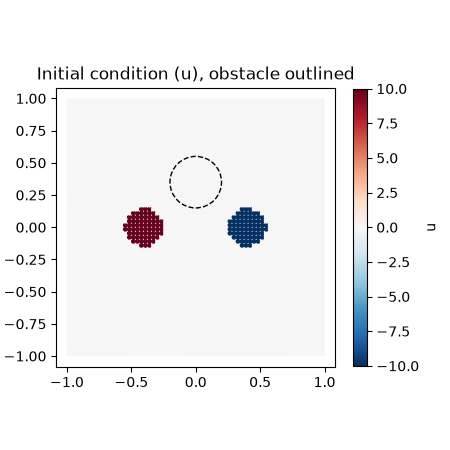

In [2]:
from warpSPH.cases.waveEquation import waveEquationCase
from warpSPH.runner import CaseSpec
from warpSPH.runner.runner import buildContext

_spec = CaseSpec(caseName=waveEquationCase.name, scheme=waveEquationCase.scheme,
                 params=dict(waveEquationCase.params)).merged(**waveEquationCase.defaults)
_spec = _spec.merged(nx=64, quiet=True, progress=False)
_ctx = buildContext(waveEquationCase, _spec)
waveEquationCase.configureScheme(_ctx)
_system = waveEquationCase.buildSystem(_ctx)
waveEquationCase.initialConditions(_ctx, _system)
print(f"nx=64 -> {_system.state.positions.shape[0]} particles, "
     f"default dt={_ctx.config.dt:.5f} (cflFactor={_spec.cflFactor})")

_pos = _system.state.positions.cpu()
fig, ax = plt.subplots(figsize=(4.5, 4.5))
sc = ax.scatter(_pos[:, 0], _pos[:, 1], c=_system.state.u.cpu(), cmap='RdBu_r',
                vmin=-10, vmax=10, s=6)
obstaclePos = waveEquationCase.params['obstaclePosition']
obstacleR = waveEquationCase.params['obstacleRadius']
ax.add_patch(mpatches.Circle(obstaclePos, obstacleR, fill=False, edgecolor='k', linestyle='--'))
ax.set_aspect('equal'); ax.set_title('Initial condition (u), obstacle outlined')
fig.colorbar(sc, ax=ax, shrink=0.8, label='u')
plt.show()

## Driving `solver=` through the frontend

`warpSPH.runner.run(case, spec)` is the fully generic entry point every
`examples/*/0N-*.py` CLI script calls — but its step loop
(`runner.py::_run`) calls `ctx.integrator.function(state=..., f=..., dt=...,
config=..., schemeConfig=..., verbose=...)` and **never forwards a
`solver=`**, because no case before this one had a reason to choose
anything but the registry default. So there's no `spec.solver` knob to set.

Every example notebook in this repo already works around exactly this kind
of per-run customization the same way: it doesn't call `run()` either, it
**unrolls the step loop explicitly** in a cell (`05-taylor-green-vortex.ipynb`
is the pattern) so it's editable in-line. We do the same thing here, adding
one line: `solver=` on the `ctx.integrator.function(...)` call.

`ctx.integrator` is resolved from `spec.integrationScheme` exactly the way
`getIntegrator(...)` resolves a name in the companion notebook — `'rungeKutta4'`
for explicit, `'backwardEuler'` / `'SDIRK2'` / etc. for anything DIRK-based
that should take a `solver=`.

In [3]:
def runWaveCase(integrationScheme, dt, tLimit, solver=None, nx=64, nSnapshots=5):
    """Build and run `waveEquationCase` for `tLimit` simulated seconds at a
    fixed `dt`, exactly the way a notebook's own unrolled step loop would --
    just parameterised over `integrationScheme`/`solver` so both the explicit
    and implicit runs below share one code path.

    Returns `(ctx, finalState, snapshots, trajectory, diverged)`:
      snapshots  -- list of (step, t, u) tuples, ~nSnapshots of them, u on CPU
      trajectory -- one `case.diagnostics(...)` dict per step (energy, uMax, vMax)
      diverged   -- True if a non-finite u was ever produced (loop stops early)
    """
    spec = CaseSpec(caseName=waveEquationCase.name, scheme=waveEquationCase.scheme,
                    params=dict(waveEquationCase.params)).merged(**waveEquationCase.defaults)
    spec = spec.merged(nx=nx, quiet=True, progress=False,
                       integrationScheme=integrationScheme, dt=dt, tLimit=tLimit)
    ctx = buildContext(waveEquationCase, spec)
    waveEquationCase.configureScheme(ctx)
    system = waveEquationCase.buildSystem(ctx)
    waveEquationCase.initialConditions(ctx, system)  # spec.dt is set, so this is a no-op here
    state = system.initializeNewState()

    nSteps = max(1, int(tLimit / dt))
    snapEvery = max(1, nSteps // (nSnapshots - 1)) if nSnapshots > 1 else nSteps
    snapshots = [(0, 0.0, state.state.u.clone().cpu())]
    trajectory = [dict(waveEquationCase.diagnostics(ctx, state), step=0, t=0.0)]

    kwargs = dict(f=ctx.stepFunction, dt=ctx.config.dt, config=ctx.config,
                 schemeConfig=ctx.schemeConfig, verbose=False)
    if solver is not None:
        kwargs['solver'] = solver

    diverged = False
    for i in range(1, nSteps + 1):
        result = ctx.integrator.function(state=state, **kwargs)
        state = result.state
        uMax = state.state.u.abs().max().item()
        if not math.isfinite(uMax):
            diverged = True
            trajectory.append({'step': i, 't': i * dt, 'uMax': float('nan')})
            break
        trajectory.append(dict(waveEquationCase.diagnostics(ctx, state), step=i, t=i * dt))
        if i % snapEvery == 0 or i == nSteps:
            snapshots.append((i, i * dt, state.state.u.clone().cpu()))

    return ctx, state, snapshots, trajectory, diverged


def plotSnapshots(snapshots, positions, title, vmax=None):
    vmax = vmax if vmax is not None else max(float(u.abs().max()) for _, _, u in snapshots)
    fig, axes = plt.subplots(1, len(snapshots), figsize=(2.6 * len(snapshots), 3), constrained_layout=True)
    if len(snapshots) == 1:
        axes = [axes]
    for ax, (step, t, u) in zip(axes, snapshots):
        sc = ax.scatter(positions[:, 0], positions[:, 1], c=u, cmap='RdBu_r',
                        vmin=-vmax, vmax=vmax, s=4)
        ax.set_title(f't={t:.3f}'); ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(title)
    fig.colorbar(sc, ax=axes, shrink=0.8, label='u')
    return fig

## Explicit (`RK4`) at the case's own default `dt`

Module warpSPHCore.coreOperations.wp_gradient 73a02bb load on device 'cuda:0' took 2.07 ms  (cached)
Module warpSPHCore.coreOperations.wp_laplacian 4d00b5c load on device 'cuda:0' took 3.57 ms  (cached)
RK4: 40 steps, diverged=False, final uMax=5.4451, final totalEnergy=1552.3396


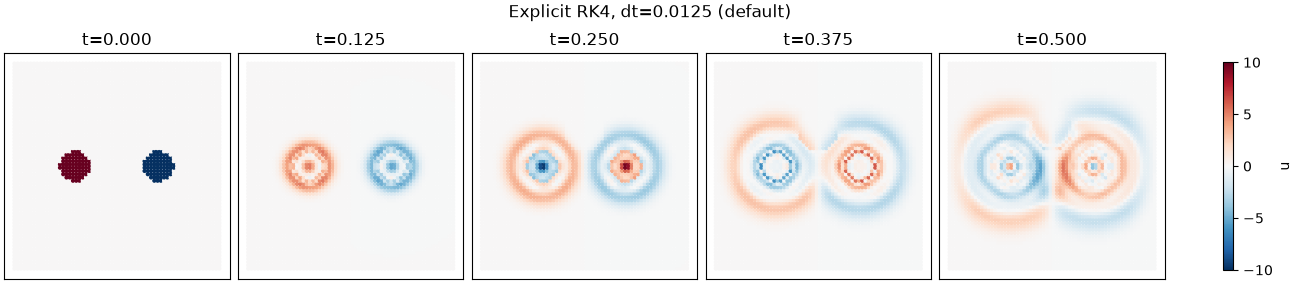

In [4]:
DT_DEFAULT = _ctx.config.dt  # from the preview cell above, cflFactor=0.1's own CFL dt
T_LIMIT = 0.5

ctxE, stateE, snapsE, trajE, divE = runWaveCase('rungeKutta4', dt=DT_DEFAULT, tLimit=T_LIMIT)
print(f'RK4: {len(trajE)-1} steps, diverged={divE}, final uMax={trajE[-1]["uMax"]:.4f}, '
     f'final totalEnergy={trajE[-1]["totalEnergy"]:.4f}')
positions = stateE.state.positions.cpu()
_ = plotSnapshots(snapsE, positions, f'Explicit RK4, dt={DT_DEFAULT:.4f} (default)')
plt.show()

## Implicit (`SDIRK2` + `JFNKSolver`) at the *same* `dt` — a correctness check

`SDIRK2` (order 2, L-stable) rather than `backwardEuler` (order 1) here, on
purpose: backward Euler is *also* correct, but at this `dt` its own
first-order numerical dissipation is large enough to swamp the comparison
(measured below) — L-stability and "matches a 4th-order explicit scheme
closely at a shared `dt`" are two different properties, and conflating them
would misrepresent what's actually being checked here. This is the same
distinction `NOTES.md` §3.6 draws for `FixedPointSolver`'s own registration
(implicit midpoint's *symplecticity* vs. its shipped default's *accuracy*
are not the same claim).

SDIRK2+JFNK: 40 steps, diverged=False, final uMax=5.4447, final totalEnergy=1534.2930


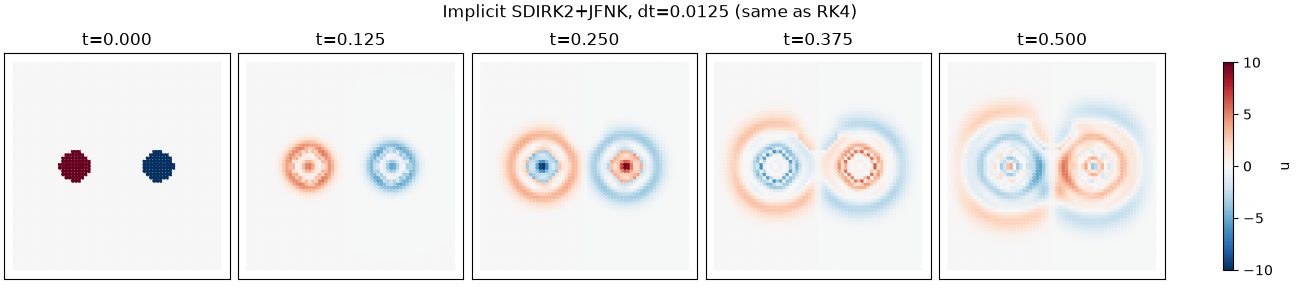

relative difference in final u field (RK4 vs. SDIRK2+JFNK): 0.077


In [5]:
from warpSPHIntegrators import JFNKSolver

solver = JFNKSolver(matvec='fd', tol=1e-6, max_iterations=15)
ctxI, stateI, snapsI, trajI, divI = runWaveCase('SDIRK2', dt=DT_DEFAULT, tLimit=T_LIMIT, solver=solver)
print(f'SDIRK2+JFNK: {len(trajI)-1} steps, diverged={divI}, final uMax={trajI[-1]["uMax"]:.4f}, '
     f'final totalEnergy={trajI[-1]["totalEnergy"]:.4f}')

vmax = max(float(u.abs().max()) for _, _, u in snapsE)
_ = plotSnapshots(snapsI, positions, f'Implicit SDIRK2+JFNK, dt={DT_DEFAULT:.4f} (same as RK4)', vmax=vmax)
plt.show()

relDiff = float(torch.linalg.norm(stateE.state.u.cpu() - stateI.state.u.cpu())
               / torch.linalg.norm(stateE.state.u.cpu()))
print(f'relative difference in final u field (RK4 vs. SDIRK2+JFNK): {relDiff:.3f}')

**What to expect**: a difference of a few percent, shrinking as `dt` shrinks
(genuine `O(dt^2)` truncation error between a 2nd- and 4th-order method, not
a discrepancy in the physics) — not the tens-of-percent difference a 1st-order
`backwardEuler` shows at this same `dt`, quantified directly below.

In [6]:
_, stateBE, _, _, _ = runWaveCase('backwardEuler', dt=DT_DEFAULT, tLimit=T_LIMIT,
                                  solver=JFNKSolver(matvec='fd', tol=1e-6, max_iterations=15))
relDiffBE = float(torch.linalg.norm(stateE.state.u.cpu() - stateBE.state.u.cpu())
                 / torch.linalg.norm(stateE.state.u.cpu()))
print(f'RK4 vs. SDIRK2+JFNK  (order 2): {relDiff:.3f} relative difference')
print(f'RK4 vs. backwardEuler+JFNK (order 1): {relDiffBE:.3f} relative difference -- own numerical dissipation, not disagreement')

RK4 vs. SDIRK2+JFNK  (order 2): 0.077 relative difference
RK4 vs. backwardEuler+JFNK (order 1): 0.489 relative difference -- own numerical dissipation, not disagreement


## The payoff: `dt` past explicit's stability limit

`RK4`'s stability here is set by the border damping term, not the acoustic
Laplacian (`cases/waveEquation.py`'s own comment: `cflFactor=0.3` already
blows up). We push `dt` to `8×` the default -- comfortably past that -- and
run both schemes for the same **number of steps** (not the same simulated
time, since one of them won't reach it).

dt=0.4000 (32x default), 10 steps
  RK4:          diverged=False, final uMax=1.96579352074183e+35
  SDIRK2+JFNK:  diverged=False, final uMax=0.4352


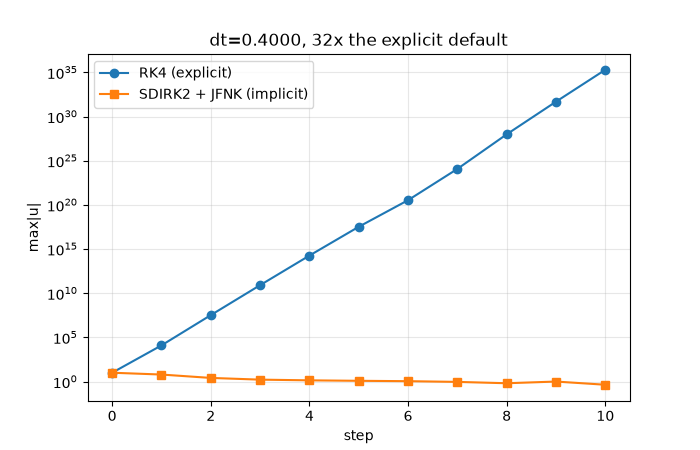

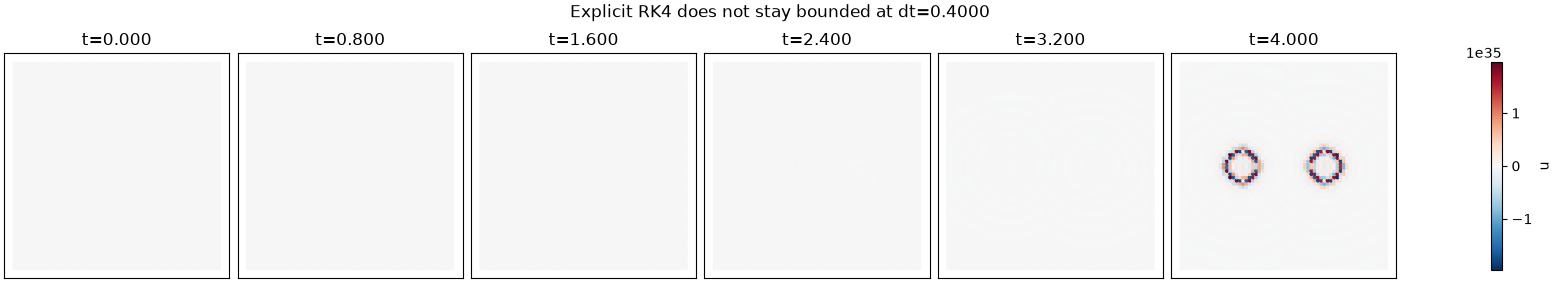

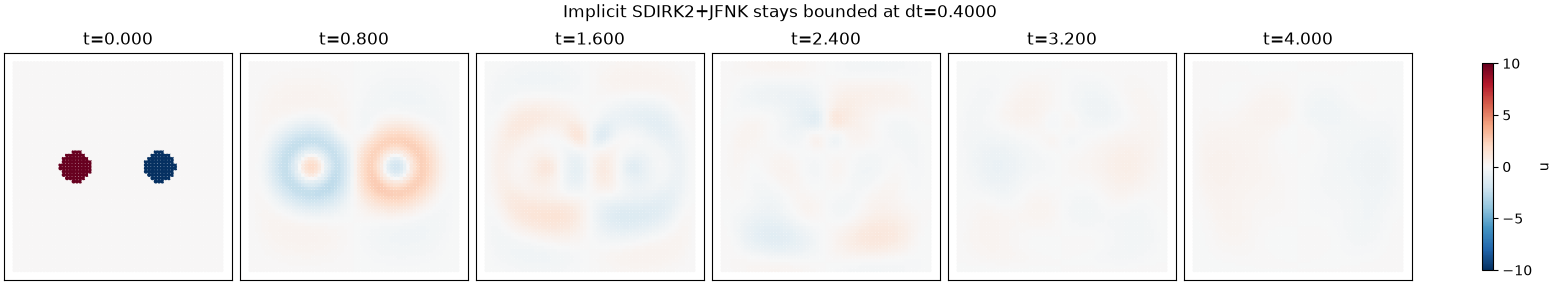

In [11]:
DT_LARGE = 32 * DT_DEFAULT
N_STEPS_LARGE = 10

ctxEL, stateEL, snapsEL, trajEL, divEL = runWaveCase('rungeKutta4', dt=DT_LARGE,
                                                     tLimit=DT_LARGE * N_STEPS_LARGE)
ctxIL, stateIL, snapsIL, trajIL, divIL = runWaveCase(
    'SDIRK2', dt=DT_LARGE, tLimit=DT_LARGE * N_STEPS_LARGE,
    solver=JFNKSolver(matvec='jvp', tol=1e-6, max_iterations=15))

print(f'dt={DT_LARGE:.4f} ({DT_LARGE/DT_DEFAULT:.0f}x default), {N_STEPS_LARGE} steps')
print(f'  RK4:          diverged={divEL}, final uMax={trajEL[-1]["uMax"]!s}')
print(f'  SDIRK2+JFNK:  diverged={divIL}, final uMax={trajIL[-1]["uMax"]:.4f}')

fig, ax = plt.subplots()
stepsE = [row['step'] for row in trajEL]
uMaxE = [abs(row['uMax']) if math.isfinite(row['uMax']) else np.nan for row in trajEL]
stepsI = [row['step'] for row in trajIL]
uMaxI = [abs(row['uMax']) for row in trajIL]
ax.semilogy(stepsE, uMaxE, 'o-', label='RK4 (explicit)')
ax.semilogy(stepsI, uMaxI, 's-', label='SDIRK2 + JFNK (implicit)')
ax.set_xlabel('step'); ax.set_ylabel('max|u|'); ax.set_title(f'dt={DT_LARGE:.4f}, {DT_LARGE/DT_DEFAULT:.0f}x the explicit default')
ax.legend(); ax.grid(True, which='both', alpha=0.3)
plt.show()

_ = plotSnapshots(snapsIL, positions, f'Implicit SDIRK2+JFNK stays bounded at dt={DT_LARGE:.4f}')
_ = plotSnapshots(snapsEL, positions, f'Explicit RK4 does not stay bounded at dt={DT_LARGE:.4f}')
plt.show()

**What to expect**: `RK4`'s `max|u|` grows by many orders of magnitude
within a handful of steps (typically past `1e9` by step 10 at this `dt`) —
this is `cases/waveEquation.py`'s own defaults comment made concrete, not a
new finding. `SDIRK2+JFNK` stays within the same handful of physical units
the default-`dt` run reached, still visibly the same two-source
interference pattern, just coarser in time. This is the 2-D, full-featured
(sources + obstacle + absorbing boundary) version of the companion
notebook's Experiment 1 (`k=1e6` oscillator / `dt=2.0` standing wave): the
same JFNK machinery, unmodified, on the case exactly as `warpsph-run
waveEquation` would build it.

## Reference

```python
from warpSPH.cases.waveEquation import waveEquationCase
from warpSPH.runner import CaseSpec
from warpSPH.runner.runner import buildContext
from warpSPHIntegrators import JFNKSolver

spec = CaseSpec(caseName=waveEquationCase.name, scheme=waveEquationCase.scheme,
                params=dict(waveEquationCase.params)).merged(**waveEquationCase.defaults)
spec = spec.merged(integrationScheme='SDIRK2', dt=0.1)   # any DIRK name: backwardEuler / implicitMidpoint / trapezoidal / SDIRK2
ctx = buildContext(waveEquationCase, spec)
waveEquationCase.configureScheme(ctx)
system = waveEquationCase.buildSystem(ctx)
waveEquationCase.initialConditions(ctx, system)
state = system.initializeNewState()

result = ctx.integrator.function(state=state, f=ctx.stepFunction, dt=ctx.config.dt,
                                 config=ctx.config, schemeConfig=ctx.schemeConfig,
                                 verbose=False, solver=JFNKSolver(matvec='fd'))
```

Swap `waveEquationCase` for any other registered `Case` (`getCase(name)` /
`listCases()` in `warpSPH.runner`) and the same pattern applies to *any*
DIRK-implicit run through the frontend — nothing here is wave-equation
specific except which case we picked to demonstrate it on. What *is*
wave-equation specific (per `JFNK_PLAN.md`) is that `matvec='jvp'` is exact
for this case's `f`: it's built entirely from the Laplacian operator, one of
`warpSPHCore`'s six JVP-wrapped operators. Try it here too — same calls,
`matvec='jvp'` instead of `'fd'`.

**Further reading**: `jfnk_solver_exploration.ipynb` (this notebook's
companion — the same solvers on the hand-built 1-D case, with the full
`JFNKSolver`/`FixedPointSolver` option reference), `warpSPHIntegrators/
JFNK_PLAN.md`, `warpSPH/src/warpSPH/cases/waveEquation.py`,
`warpSPH/src/warpSPH/runner/runner.py`.